In [19]:
import ee
from rich.jupyter import display
from sympy.stats.sampling.sample_numpy import numpy

ee.Authenticate()

True

In [20]:
ee.Initialize(project="climateconsciousimli")  # assumes you've authenticated already

In [21]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import torch
import numpy as np

In [22]:
# Define bounding box (lon_min, lat_min, lon_max, lat_max)
lat_min, lat_max = 28.0, 29.39
lat_avg = (lat_max + lat_min) / 2
lon_min, lon_max = 76.3, 79.0
lon_avg = (lon_max + lon_min) / 2

stepp = 0.25


roi = ee.Geometry.Rectangle([lon_min, lat_min, lon_max, lat_max])
pixel = ee.Geometry.Point([77.0, 29.0])
micropixel = ee.Geometry.Rectangle([lon_avg-stepp, lat_avg-stepp, lon_avg+stepp, lat_avg+stepp])
sampling_scale = 2500
start_date = '2024-02-05'
end_date = '2024-02-06'

- Everything is the same till now.
- `scale` is \~8km.
- `pixel` is one point.
- `roi` is the region.
- `micropixel` is a smaller region to make computation easier
- Now collect the data accordingly :

In [23]:
"""
Can define multiple collections (wind, SO2, NO2). Prepare what we're doing for each. Then feed outputs for all. No merging required as such, except right before training/input into a model.
"""

collection = (
    ee.ImageCollection("COPERNICUS/S5P/OFFL/L3_NO2")
    .filterBounds(roi)# REPLACE WITH ROI
    .filterDate(start_date, end_date)
    .select('tropospheric_NO2_column_number_density')
)

- The function `make_coarse` given below is of interest. In words (which I myself don't fully understand yet), it takes in raw data, reduces its resolution by taking a mean (how is that done/executed?). It then "reprojeccts" the data, with some scale in mind, giving us the "coarse" data.
- The raw data has each pixel representing ~7km$^2$. We do not wish to work with this. To "access" the data, we call several functions :
-   `reduceResolution`
-   `reproject` onto the grid.
-   `focal_mean` : treat "Null" by taking a spatial mean.
-   `copyProperties` : preserves `system:time_start`.

In [24]:
def make_coarse(image):
    return (image
        .reduceResolution(
            reducer=ee.Reducer.mean(),
            bestEffort=True
        )
        .reproject(
            scale=1100,
            crs='EPSG:4326'
        ).focal_mean(radius=2, units='pixels')
        .copyProperties(image, ['system:time_start'])
    )

coarse_collection = collection.map(make_coarse) # This (possibly coarse) collection will be henceforth be used.

size_of_coll = coarse_collection.size().getInfo()
print(f"Size of collection is {size_of_coll}. In particular, coarse_collection.getInfo()['features'] has that many items.")
print()
print(f"This means we have ~{size_of_coll} entries in the given time range. For each of these, we have an image (11px by 11px) of the entire region we have (after reducing resolution) So if we have {size_of_coll} measurements for the region, and the region is (say) 11*11 pixels, then we have ~{11*11*size_of_coll} measurements. Many of these may be null!")
# print(coarse_collection.first().getInfo()['properties']['system:time_start']) # need to parse as date-time

Size of collection is 14. In particular, coarse_collection.getInfo()['features'] has that many items.

This means we have ~14 entries in the given time range. For each of these, we have an image (11px by 11px) of the entire region we have (after reducing resolution) So if we have 14 measurements for the region, and the region is (say) 11*11 pixels, then we have ~1694 measurements. Many of these may be null!


In [25]:
def sample_image(image):
    samples = image.sample(
        region=roi,
        scale=sampling_scale,
        geometries=True,
        dropNulls=True
    )
    # return samples.map(lambda f: f.set('system:time_start', f.getInfo()['properties']['system:time_start'])).map(lambda f: f.set(
    #     'date', image.date().format('YYYY-MM-dd')
    # ))
    time_start = image.get('system:time_start')
    return samples.map(lambda f: f.set({
        # 'system:time_start': time_start,
        'date': ee.Date(time_start).format('YYYY-MM-dd'),
        'datetime': ee.Date(time_start).format('YYYY-MM-dd HH:mm:ss')
    }))

fc = coarse_collection.map(sample_image).flatten()
print(f"Now we have reduced our region of interest from roi to micropixel or pixel. We retain null values and the data we keep is as below :")

Now we have reduced our region of interest from roi to micropixel or pixel. We retain null values and the data we keep is as below :


In [26]:
features = fc.getInfo()['features']
# print(f"Features are : \n\n{features}\n\n")
proppies = features[0]['properties'] # ['tropospheric_NO2_column_number_density'])
print(f"Following is 'fc.getInfo()['features'][0]['properties']', that is, the properties relating to the first (hence `0`) feature that we have. One can expect to see date, date-time, and NO2 value (if not null) : \n\n{proppies}\n\n")
print()
print(f"proppies.get('tropospheric_NO2_column_number_density') gives {proppies.get('tropospheric_NO2_column_number_density')}")
print("This applies for proppies being the first record in the given time range. Now we will try them all out ....\n\n\n")


n_feature_instances = len(features)
print(f"number of 'features' is {n_feature_instances}, as we calculated above.")
print(features[0].get('properties'))
for i in range(n_feature_instances):
    print(features[i]['properties'].get('tropospheric_NO2_column_number_density'), features[i]['properties'].get('datetime'))
# for j in proppies:
#     print(j)
#     print()

Following is 'fc.getInfo()['features'][0]['properties']', that is, the properties relating to the first (hence `0`) feature that we have. One can expect to see date, date-time, and NO2 value (if not null) : 

{'date': '2024-02-05', 'datetime': '2024-02-05 07:11:28', 'tropospheric_NO2_column_number_density': 2.9751239600123054e-05}



proppies.get('tropospheric_NO2_column_number_density') gives 2.9751239600123054e-05
This applies for proppies being the first record in the given time range. Now we will try them all out ....



number of 'features' is 4085, as we calculated above.
{'date': '2024-02-05', 'datetime': '2024-02-05 07:11:28', 'tropospheric_NO2_column_number_density': 2.9751239600123054e-05}
2.9751239600123054e-05 2024-02-05 07:11:28
2.9751239746851488e-05 2024-02-05 07:11:28
2.7652561732943467e-05 2024-02-05 07:11:28
2.4744025890034317e-05 2024-02-05 07:11:28
2.370508355184321e-05 2024-02-05 07:11:28
2.4317770467335105e-05 2024-02-05 07:11:28
2.5890958246291453e-05 2024-02-05 

In [27]:
features = fc.getInfo()['features']

rows = []
for f in features:
    props = f['properties']
    coords = f['geometry']['coordinates']

    if 'tropospheric_NO2_column_number_density' in props:
        rows.append({
            'lon': coords[0],
            'lat': coords[1],
            'date': props['date'],
            'datetime': props['datetime'],
            'NO2': props['tropospheric_NO2_column_number_density']
        })

df = pd.DataFrame(rows)
df

,lon,lat,date,datetime,NO2
0,77.782875,29.386139,2024-02-05,2024-02-05 07:11:28,0.000030
1,77.805333,29.386139,2024-02-05,2024-02-05 07:11:28,0.000030
2,77.827790,29.386139,2024-02-05,2024-02-05 07:11:28,0.000028
3,77.850248,29.386139,2024-02-05,2024-02-05 07:11:28,0.000025
4,77.872706,29.386139,2024-02-05,2024-02-05 07:11:28,0.000024
...,...,...,...,...,...
4080,78.142201,28.016208,2024-02-05,2024-02-05 07:11:28,0.000059
4081,78.164659,28.016208,2024-02-05,2024-02-05 07:11:28,0.000057
4082,78.187117,28.016208,2024-02-05,2024-02-05 07:11:28,0.000045
4083,78.209574,28.016208,2024-02-05,2024-02-05 07:11:28,0.000034


In [28]:
unique_dates = sorted(df['date'].unique())
print(len(df['date']))
selected_dates = unique_dates[:]

4085


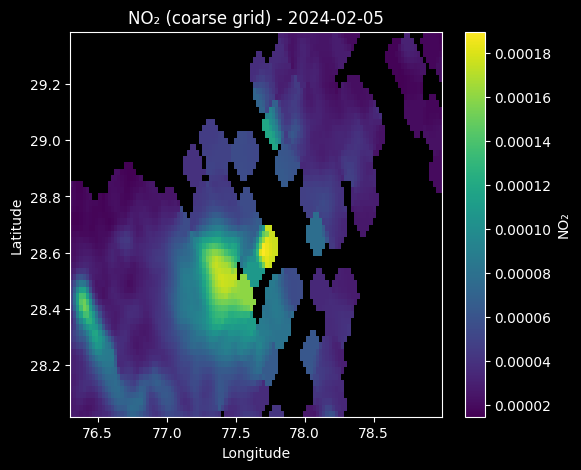

In [29]:
for d in selected_dates:
    subset = df[df['date'] == d]

    # Create grid
    pivot = subset.pivot_table(
        index='lat',
        columns='lon',
        values='NO2'
    )
    pivot.fillna(0)

    plt.figure(figsize=(6,5))
    plt.imshow(
        pivot.values,
        extent=(
            pivot.columns.min(), pivot.columns.max(),
            pivot.index.min(), pivot.index.max()
        ),
        origin='lower',
        aspect='auto'
    )
    plt.colorbar(label='NO₂')
    plt.title(f'NO₂ (coarse grid) - {d}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()

In [33]:
import pandas as pd
import numpy as np

# 1. Create a copy and ensure datetime types
df_interp = df.copy()
df_interp['datetime'] = pd.to_datetime(df_interp['datetime'])

# 2. Create complete grid
all_lats = df_interp['lat'].unique()
all_lons = df_interp['lon'].unique()
all_times = sorted(df_interp['datetime'].unique())

index = pd.MultiIndex.from_product([all_lats, all_lons, all_times], names=['lat', 'lon', 'datetime'])
full_df = pd.DataFrame(index=index).reset_index()

# Merge original data
df_merged = pd.merge(full_df, df_interp, on=['lat', 'lon', 'datetime'], how='left')
df_merged = df_merged.sort_values(['lat', 'lon', 'datetime'])

# --- Logic to fill date only if previous and next dates are the same ---
def conditional_date_fill(group):
    # We access the column directly; grouping columns are present if include_groups=True (default)
    prev_date = group['date'].ffill()
    next_date = group['date'].bfill()
    mask = group['date'].isna() & (prev_date == next_date)
    group.loc[mask, 'date'] = prev_date[mask]
    return group

# We must keep the groups to ensure 'lat' and 'lon' remain in the dataframe
df_merged = df_merged.groupby(['lat', 'lon'], group_keys=True).apply(conditional_date_fill)

# 3. Interpolate NO2 values
df_merged['NO2_interpolated'] = df_merged.groupby(['lat', 'lon'])['NO2'].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both')
)

print("Original row count:", len(df))
print("Expanded row count:", len(df_merged))
print("Example of filled dates:")
print(df_merged.head(20))

Original row count: 4085
Expanded row count: 7316
Example of filled dates:
                                    datetime        date       NO2  \
lat       lon                                                        
28.016208 76.300654 7290 2024-02-05 07:11:28  2024-02-05  0.000027   
          76.323112 7291 2024-02-05 07:11:28  2024-02-05  0.000028   
          76.345570 7292 2024-02-05 07:11:28  2024-02-05  0.000027   
          76.368028 7293 2024-02-05 07:11:28  2024-02-05  0.000025   
          76.390486 7299 2024-02-05 07:11:28  2024-02-05  0.000026   
          76.412944 7300 2024-02-05 07:11:28  2024-02-05  0.000025   
          76.435402 7305 2024-02-05 07:11:28  2024-02-05  0.000027   
          76.457860 7312 2024-02-05 07:11:28  2024-02-05  0.000030   
          76.480318 7313 2024-02-05 07:11:28  2024-02-05  0.000032   
          76.502775 7306 2024-02-05 07:11:28  2024-02-05  0.000033   
          76.525233 7307 2024-02-05 07:11:28  2024-02-05  0.000035   
          76.54